Gaussian Processes   
https://scikit-learn.org/stable/modules/gaussian_process.html

In [1]:
import numpy as np
from numpy import random as rng
from matplotlib import pyplot as plt

(1024, 1)

(1024, 1)

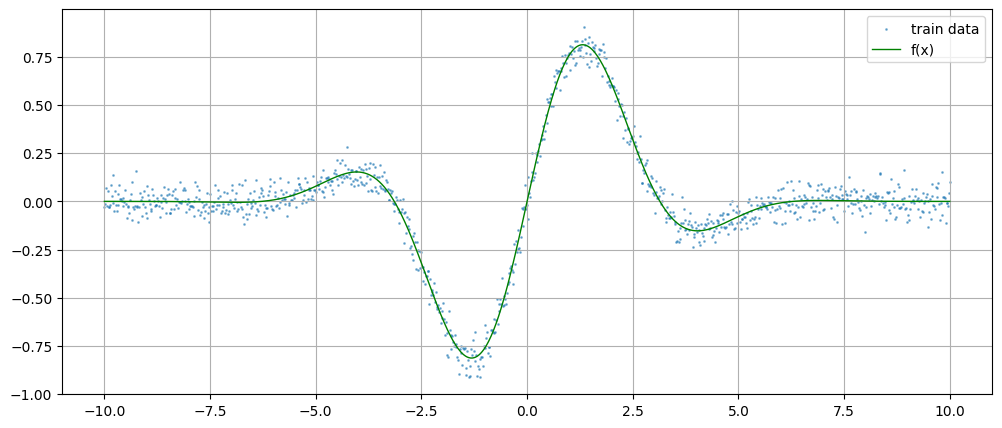

In [2]:
# Аппроксимация нелинейной функции f(x) = sin(x) · exp(-x²/10)

# f, xlim = lambda x: np.sin(x*2.9),(-1.,+2.)
# f, xlim = lambda x: np.sin(x*2.9)+np.cos(x*5.9),(-1., 1.)
# f, xlim = lambda x: np.exp( -np.square(x) ) + 1.5 * np.exp(-np.square(x-2) ), (-3,5)
f, xlim = lambda x: np.sin(x)*np.exp(-np.square(x)*0.1), ( -10., +10. )

x = np.linspace(xlim[0],xlim[1],1024).reshape(-1, 1)
y_true = f(x)
y = y_true + rng.normal(0.0, 0.05, x.shape)
display( x.shape, y.shape )

fig,ax = plt.subplots(1,figsize=(12,5))
ax.scatter( x, y, s=1, alpha=.5, label='train data')
ax.plot( x, y_true, 'g-', linewidth=1, label='f(x)')
ax.legend()
ax.grid()
plt.show()


In [26]:
# from sklearn.datasets import make_friedman2
# X,y = make_friedman2(n_samples=1024, noise=0, random_state=0)
# print(X.shape,y.shape)

In [3]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)
display( (x_train.shape, y_train.shape,), (x_test.shape,y_test.shape) )

((716, 1), (716, 1))

((308, 1), (308, 1))

In [16]:
from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF
# model = GaussianProcessRegressor( kernel=RBF()).fit(x_train, y_train)

from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
# kernel = DotProduct() + WhiteKernel()

model = GaussianProcessRegressor( kernel = DotProduct() + WhiteKernel() ).fit(x_train, y_train)


In [17]:
# model.predict(x_train)
# model.predict(x_test)

In [ ]:
# from sklearn.gaussian_process import GaussianProcessClassifier
# from sklearn.gaussian_process.kernels import RBF
# kernel = 1.0 * RBF(1.0)
# gpc = GaussianProcessClassifier(kernel=kernel,    random_state=0).fit(X, y)
# gpc.score(X, y)

In [19]:
i_train = np.argsort(x_train,axis=0).flatten()
x_train = x_train[i_train]
y_train = y_train[i_train]

i_test = np.argsort(x_test,axis=0).flatten()
x_test = x_test[i_test]
y_test = y_test[i_test]

In [20]:
o_train = model.predict( x_train )
o_test = model.predict( x_test )

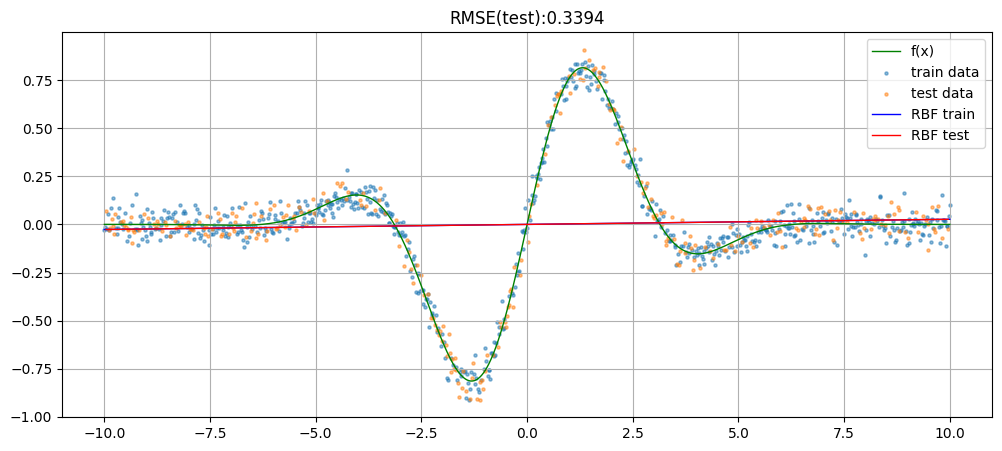

In [21]:
rmse = np.sqrt( np.square( o_test - f(x_test)).mean() )

fig,ax = plt.subplots(1,figsize=(12,5))
ax.plot( x, y_true, 'g-', linewidth=1, label='f(x)')
ax.scatter( x_train, y_train, s=5, alpha=.5, label='train data')
ax.scatter( x_test, y_test, s=5, alpha=.5, label='test data')
ax.plot( x_train, o_train, 'b-', linewidth=1, label='RBF train')
ax.plot( x_test, o_test, 'r-', linewidth=1, label='RBF test')
ax.set_title(f"RMSE(test):{rmse:.4f}" )
ax.grid()
ax.legend()
plt.show()
